# Gabarito — Segmentação de clientes com K-Means

Solução comentada da Atividade 1.

**Arquivo de dados:** `clientes_kmeans.csv`

> Regra central: as colunas de referência servem somente para avaliar o resultado no final. Elas não podem entrar em `X`.

## 1. Bibliotecas e leitura

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEMENTE = 42

In [2]:
df = pd.read_csv("clientes_kmeans.csv")
display(df.head())
print("Dimensoes:", df.shape)
display(df.describe(include="all"))
print("Ausentes por coluna:\n", df.isna().sum())

,cliente_id,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra,perfil_referencia
0,CLI001,31,1881,3,132.49,58,economico
1,CLI002,51,2408,3,220.06,46,economico
2,CLI003,51,2529,1,118.88,49,economico
3,CLI004,26,2769,2,91.25,60,economico
4,CLI005,28,4083,1,116.21,12,economico


Dimensoes: (90, 7)


,cliente_id,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra,perfil_referencia
count,90,90.000000,90.000000,90.000000,90.000000,90.000000,90
unique,90,NaN,NaN,NaN,NaN,NaN,3
top,CLI001,NaN,NaN,NaN,NaN,NaN,economico
freq,1,NaN,NaN,NaN,NaN,NaN,30
mean,NaN,41.655556,6762.344444,4.922222,554.964444,21.644444,NaN
std,NaN,10.373000,3600.640224,2.623266,443.653484,16.405885,NaN
min,NaN,18.000000,1881.000000,1.000000,58.600000,1.000000,NaN
25%,NaN,34.000000,3508.000000,3.000000,150.627500,9.250000,NaN
50%,NaN,42.000000,5872.500000,5.000000,378.505000,16.000000,NaN
75%,NaN,49.000000,10526.250000,7.000000,1079.127500,31.750000,NaN


Ausentes por coluna:
 cliente_id                  0
idade                       0
renda_mensal                0
visitas_mes                 0
gasto_medio                 0
dias_desde_ultima_compra    0
perfil_referencia           0
dtype: int64


## 2. Preparação e padronização

O identificador e a referência são excluídos. A padronização impede que a renda domine as distâncias apenas por possuir números maiores.

In [3]:
colunas = ["idade", "renda_mensal", "visitas_mes", "gasto_medio", "dias_desde_ultima_compra"]
X = df[colunas]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

## 3. Método do cotovelo e silhueta

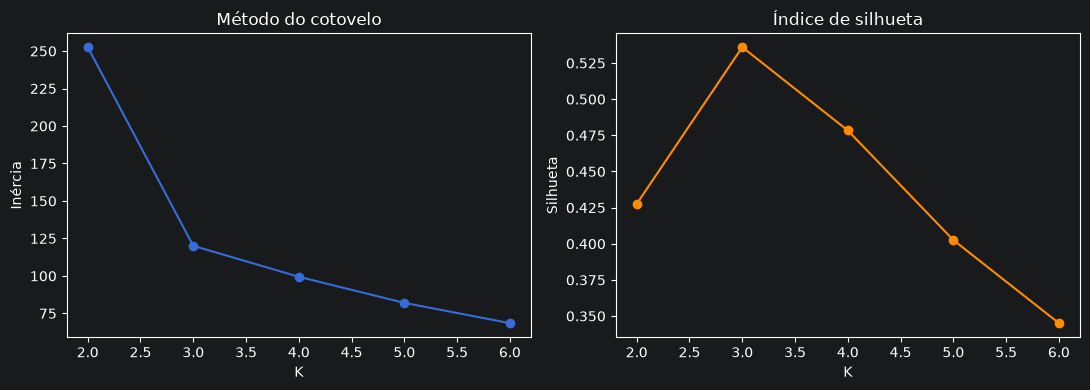

In [4]:
valores_k = range(2, 7)
inercias, silhuetas = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    grupos = modelo.fit_predict(X_padronizado)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, grupos))

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="K", ylabel="Inércia")
eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Índice de silhueta", xlabel="K", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 4. Modelo final e perfil dos grupos

In [5]:
kmeans = KMeans(n_clusters=3, random_state=SEMENTE, n_init=10)
clusters = kmeans.fit_predict(X_padronizado)
df["cluster"] = clusters
resumo = df.groupby("cluster")[colunas].mean().round(2)
display(resumo)

,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra
cluster,,,,,
0,34.47,5892.07,7.90,392.42,6.83
1,47.23,11331.67,4.60,1148.81,17.83
2,43.27,3063.30,2.27,123.66,40.27


## 5. Visualização em duas dimensões com PCA

O PCA é usado apenas para representar visualmente as cinco dimensões em um plano.

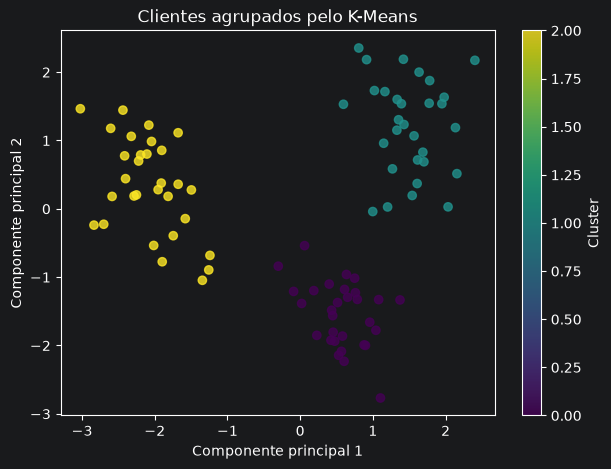

In [6]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_padronizado)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clientes agrupados pelo K-Means")
plt.colorbar(label="Cluster")
plt.show()

## 6. Avaliação externa

A referência entra somente depois do agrupamento. O ARI não exige que os números dos clusters coincidam com os nomes.

In [7]:
tabela = pd.crosstab(df["perfil_referencia"], df["cluster"], rownames=["referencia"], colnames=["cluster"])
ari = adjusted_rand_score(df["perfil_referencia"], clusters)
display(tabela)
print(f"ARI: {ari:.4f}")

cluster,0,1,2
referencia,,,
economico,0,0,30
frequente,30,0,0
premium,0,30,0


ARI: 1.0000


## 7. Interpretação esperada

- K=3 deve aparecer como uma escolha forte no cotovelo e na silhueta.
- Um grupo tende a ser econômico: menor renda e gasto, poucas visitas e maior recência.
- Outro tende a ser frequente: mais visitas e compra recente.
- O terceiro tende a ser premium: renda e gasto elevados.
- Um ARI alto indica concordância entre os grupos descobertos e os perfis de referência.
- Sem padronização, `renda_mensal` e `gasto_medio` dominariam a distância euclidiana.